# Restaurant Sales Forecasting — 4 Models, 2 Horizons (1-Day / 7-Day)

Run top to bottom in Google Colab. Upload `Restaurant__transactions.xlsx` when prompted in the first code cell.

**Models included (4):**
1. Linear Regression (tabular ML)
2. Random Forest (tabular ML)
3. XGBoost (tabular ML)
4. LSTM (deep learning)


In [1]:
# Install/import
!pip install -q scikit-learn pandas matplotlib openpyxl xgboost tensorflow

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
tf.get_logger().setLevel("ERROR")
tf.random.set_seed(42)
np.random.seed(42)

print("Libraries loaded.")


Libraries loaded.


In [2]:
# Upload the transactions file (Colab file picker)
from google.colab import files
uploaded = files.upload()  # choose Restaurant__transactions.xlsx
FILE_PATH = list(uploaded.keys())[0]


Saving Restaurant__transactions.xlsx to Restaurant__transactions.xlsx


## Data Loading & Cleaning

In [3]:
df = pd.read_excel(FILE_PATH, sheet_name="Sheet1")
df["Date"] = pd.to_datetime(df["Date"])
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns: {list(df.columns)}")
print(df.dtypes)
display(df.head(3))
display(df.tail(3))


Loaded 22896 rows, 5 columns: ['Date', 'Time', 'Item', 'UnitPrice', 'TotalSales']
Date          datetime64[ns]
Time                  object
Item                  object
UnitPrice            float64
TotalSales           float64
dtype: object


,Date,Time,Item,UnitPrice,TotalSales
0,2026-06-10,12:23:23,Test Kitchen,0.01,0.0345
1,2026-06-10,12:23:23,Test Bar,0.01,0.0230
2,2026-06-10,12:23:23,Test Juice,0.01,0.0115


,Date,Time,Item,UnitPrice,TotalSales
22893,2026-08-08,22:08:05,Room Service,158.15,200.0655
22894,2026-08-08,22:11:34,Coffee,67.19,84.9965
22895,2026-08-09,07:49:17,Yejebna Buna,55.34,70.0005


In [4]:
min_date, max_date = df["Date"].min(), df["Date"].max()
total_days = (max_date - min_date).days + 1
print(f"Date range: {min_date.date()} to {max_date.date()} ({total_days} calendar days)")

full_range = pd.date_range(min_date, max_date, freq="D")
present_days = set(df["Date"].dt.date)
missing_days = [d.date() for d in full_range if d.date() not in present_days]
print(f"Missing calendar days: {len(missing_days)}")

print("\nTotalSales stats:")
print(df["TotalSales"].describe(percentiles=[.1,.25,.5,.75,.9,.99]))

n_test_items = df["Item"].str.contains("Test", case=False).sum()
print(f"\nRows with 'Test' in Item name: {n_test_items} (NOTE: Test Kitchen / Test Bar / Test Juice are real menu items, not junk rows -- kept below)")


Date range: 2026-06-10 to 2026-08-09 (61 calendar days)
Missing calendar days: 0

TotalSales stats:
count     22896.000000
mean        663.216436
std        5255.306877
min           0.011500
10%          70.000500
25%          95.001500
50%         210.013000
75%         649.991500
90%        1270.002500
99%        4800.019500
max      433679.766000
Name: TotalSales, dtype: float64

Rows with 'Test' in Item name: 76 (NOTE: Test Kitchen / Test Bar / Test Juice are real menu items, not junk rows -- kept below)


In [7]:

df_clean = df.copy()
print(f"Keeping all {len(df_clean)} rows, including Test Kitchen / Test Bar / Test Juice.")

daily = (df_clean.groupby(df_clean["Date"].dt.floor("D"))["TotalSales"]
         .sum().reset_index())
daily.columns = ["Date", "TotalSales"]
daily = daily.sort_values("Date").reset_index(drop=True)

print(f"Daily series: {len(daily)} days, {daily['Date'].min().date()} to {daily['Date'].max().date()}")
print(f"Missing values in daily TotalSales: {daily['TotalSales'].isna().sum()}")
display(daily.head())


Keeping all 22896 rows, including Test Kitchen / Test Bar / Test Juice.
Daily series: 61 days, 2026-06-10 to 2026-08-09
Missing values in daily TotalSales: 0


,Date,TotalSales
0,2026-06-10,0.3680
1,2026-06-11,210960.4850
2,2026-06-12,215435.2730
3,2026-06-13,268560.5350
4,2026-06-14,182505.2185


## Feature Engineering & Targets

In [8]:
f = daily.copy()
f["day_index"] = np.arange(len(f))
f["day_of_week"] = f["Date"].dt.dayofweek
f["is_weekend"] = (f["day_of_week"] >= 5).astype(int)
f["dow_sin"] = np.sin(2*np.pi*f["day_of_week"]/7)
f["dow_cos"] = np.cos(2*np.pi*f["day_of_week"]/7)


In [9]:
for lag in [1,2,3,5,7,14]:
    f[f"lag_{lag}"] = f["TotalSales"].shift(lag)


In [10]:
for w in [3,7,14]:
    f[f"rolling_mean_{w}"] = f["TotalSales"].shift(1).rolling(w).mean()
    f[f"rolling_std_{w}"]  = f["TotalSales"].shift(1).rolling(w).std()
for w in [3,7]:
    f[f"rolling_min_{w}"] = f["TotalSales"].shift(1).rolling(w).min()
    f[f"rolling_max_{w}"] = f["TotalSales"].shift(1).rolling(w).max()


In [11]:
f["daily_change"] = f["TotalSales"].pct_change()
f["weekly_change"] = f["TotalSales"].pct_change(7)
dow_avg = f.groupby("day_of_week")["TotalSales"].transform("mean")
f["dow_avg"] = dow_avg
f["sales_to_dow_avg"] = f["TotalSales"] / f["dow_avg"]
f["sales_to_ma_7"] = f["TotalSales"] / f["rolling_mean_7"]
f["sales_to_ma_14"] = f["TotalSales"] / f["rolling_mean_14"]
f["std_ratio_3_7"] = f["rolling_std_3"] / f["rolling_std_7"]

feature_cols_all = [c for c in f.columns if c not in ["Date","TotalSales"]]
f_clean = f.dropna(subset=feature_cols_all).reset_index(drop=True)
print(f"Rows before dropna: {len(f)}  ->  after dropna: {len(f_clean)}")
print(f"Usable date range: {f_clean['Date'].min().date()} to {f_clean['Date'].max().date()}")


Rows before dropna: 61  ->  after dropna: 47
Usable date range: 2026-06-24 to 2026-08-09


In [12]:
f_clean["target_1d"] = f_clean["TotalSales"].shift(-1)
f_clean["target_7d"] = f_clean["TotalSales"].rolling(7).sum().shift(-7)

for h in ["target_1d","target_7d"]:
    print(f"{h}: {f_clean[h].notna().sum()} usable rows")

full_data = f_clean.copy()


target_1d: 46 usable rows
target_7d: 40 usable rows


In [13]:
feat_1d = ["lag_1","lag_2","lag_3","rolling_mean_3","rolling_mean_7","rolling_std_3",
           "is_weekend","dow_sin","dow_cos"]
feat_7d = ["lag_7","lag_14","rolling_mean_7","rolling_mean_14","rolling_std_7",
           "dow_sin","dow_cos","is_weekend","sales_to_ma_7","weekly_change"]

horizon_feats = {"1d": feat_1d, "7d": feat_7d}
horizon_h = {"1d": 1, "7d": 7}   # forecast horizon in days, used by the LSTM model below

for h, feats in horizon_feats.items():
    missing = [c for c in feats if c not in full_data.columns]
    assert not missing, f"Missing engineered features for {h}: {missing}"
print("All selected features exist in the dataset.")


All selected features exist in the dataset.


## Train/Test Split & Model Training

In [14]:
MIN_TEST_ROWS = 3   # below this we consider a horizon too data-starved to evaluate meaningfully

datasets = {}
for h, feats in horizon_feats.items():
    tgt = f"target_{h}"
    sub = full_data.dropna(subset=feats+[tgt]).reset_index(drop=True)
    n = len(sub)
    split = int(n*0.8)
    n_test = n - split
    if n < 5 or n_test < MIN_TEST_ROWS:
        print(f"[{h}] SKIPPED for tabular ML models — only {n} usable rows ({n_test} would land in test).")
        datasets[h] = None
        continue

    X = sub[feats].values
    y = sub[tgt].values
    dates = sub["Date"].values

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    dates_train, dates_test = dates[:split], dates[split:]

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    datasets[h] = dict(X_train=X_train_s, X_test=X_test_s, y_train=y_train, y_test=y_test,
                        dates_train=dates_train, dates_test=dates_test,
                        feats=feats, scaler=scaler, sub=sub)
    print(f"[{h}] train n={len(X_train)}, test n={len(X_test)}")


[1d] train n=36, test n=10
[7d] train n=32, test n=8


In [15]:
tabular_results = {}   # tabular_results[h][model_name] = fitted model

for h, d in datasets.items():
    if d is None:
        continue
    print(f"\n--- Horizon {h} (train n={len(d['X_train'])}, test n={len(d['X_test'])}) ---")

    models = {}

    lr = LinearRegression()
    lr.fit(d["X_train"], d["y_train"])
    models["lr"] = lr

    n_train = len(d["X_train"])
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=None if n_train > 100 else 6,
        min_samples_split=2 if n_train > 100 else 5,
        min_samples_leaf=1 if n_train > 100 else 2,
        random_state=42,
    )
    rf.fit(d["X_train"], d["y_train"])
    models["rf"] = rf

    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        verbosity=0,
    )
    xgb.fit(d["X_train"], d["y_train"])
    models["xgb"] = xgb

    tabular_results[h] = models
    print(f"Trained: {list(models.keys())}")



--- Horizon 1d (train n=36, test n=10) ---
Trained: ['lr', 'rf', 'xgb']

--- Horizon 7d (train n=32, test n=8) ---
Trained: ['lr', 'rf', 'xgb']


In [16]:
ts_series = daily.set_index("Date")["TotalSales"].asfreq("D")
print(f"Univariate series length: {len(ts_series)} days")

def valid_origins_for_horizon(series, h):
    """Indices i (0-based, into `series`) where a full h-day-ahead target exists."""
    n = len(series)
    return list(range(0, n - h))

def chrono_split_origins(origins, test_frac=0.2, min_test=MIN_TEST_ROWS):
    n = len(origins)
    split = int(n * (1 - test_frac))
    train_o, test_o = origins[:split], origins[split:]
    if len(test_o) < min_test:
        return train_o, []
    return train_o, test_o

ts_origins = {}
for h_name, h in horizon_h.items():
    origins = valid_origins_for_horizon(ts_series, h)
    train_o, test_o = chrono_split_origins(origins)
    ts_origins[h_name] = dict(train=train_o, test=test_o)
    if not test_o:
        print(f"[{h_name}] SKIPPED for time-series models — not enough post-history days to "
              f"forecast {h} days ahead and still have a test window (series only has "
              f"{len(ts_series)} days).")
    else:
        print(f"[{h_name}] TS walk-forward: {len(train_o)} train origins, {len(test_o)} test origins")


Univariate series length: 61 days
[1d] TS walk-forward: 48 train origins, 12 test origins
[7d] TS walk-forward: 43 train origins, 11 test origins


In [17]:
def actual_target(series, origin, h):
    """Ground truth: sum of the h days AFTER `origin` (matches target_1d/7d definitions)."""
    return series.iloc[origin+1: origin+1+h].sum()

ts_predictions = {}   # ts_predictions[h_name][model_name] = list of preds aligned to test origins
ts_actuals = {}        # ts_actuals[h_name] = list of actual targets aligned to test origins

for h_name, h in horizon_h.items():
    test_o = ts_origins[h_name]["test"]
    if test_o:
        ts_actuals[h_name] = [actual_target(ts_series, o, h) for o in test_o]
    else:
        ts_actuals[h_name] = []
    ts_predictions[h_name] = {}


In [18]:
# --- LSTM (trained once on the training window, then used to forecast iteratively/
# recursively -- feeding its own predictions back in -- from each walk-forward origin)
LOOKBACK = 7

def make_lstm_dataset(values, lookback):
    X, y = [], []
    for i in range(lookback, len(values)):
        X.append(values[i-lookback:i])
        y.append(values[i])
    return np.array(X), np.array(y)

def run_lstm_walkforward(series, h_name, h):
    test_o = ts_origins[h_name]["test"]
    train_o = ts_origins[h_name]["train"]
    if not test_o or len(train_o) < LOOKBACK + 10:
        print(f"[{h_name}] LSTM skipped — not enough training history for a {LOOKBACK}-day lookback window.")
        return [np.nan]*len(test_o) if test_o else None

    values = series.values.astype("float32")
    train_end = train_o[-1]
    train_vals = values[:train_end+1]

    vmean, vstd = train_vals.mean(), train_vals.std() + 1e-8
    norm = lambda x: (x - vmean) / vstd
    denorm = lambda x: x * vstd + vmean

    Xtr, ytr = make_lstm_dataset(norm(train_vals), LOOKBACK)
    Xtr = Xtr.reshape((-1, LOOKBACK, 1))

    model = Sequential([
        LSTM(32, activation="tanh", input_shape=(LOOKBACK, 1)),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    model.fit(Xtr, ytr, epochs=60, batch_size=8, verbose=0)

    preds = []
    for o in test_o:
        window = norm(values[o-LOOKBACK+1: o+1]).reshape(1, LOOKBACK, 1)
        window = window.copy()
        step_preds = []
        for _ in range(h):
            next_norm = model.predict(window, verbose=0)[0, 0]
            step_preds.append(denorm(next_norm))
            window = np.roll(window, -1, axis=1)
            window[0, -1, 0] = next_norm
        preds.append(sum(step_preds) if h > 1 else step_preds[0])
    return preds

for h_name, h in horizon_h.items():
    if not ts_origins[h_name]["test"]:
        continue
    print(f"Fitting LSTM for horizon {h_name}...")
    ts_predictions[h_name]["lstm"] = run_lstm_walkforward(ts_series, h_name, h)


Fitting LSTM for horizon 1d...
Fitting LSTM for horizon 7d...


## Evaluation & Results

In [19]:
MODEL_LABELS = {
    "lr": "Linear Regression", "rf": "Random Forest", "xgb": "XGBoost", "lstm": "LSTM",
}

def safe_metrics(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]
    if len(y_true) == 0:
        return None
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan
    nonzero = y_true != 0
    mape = (np.abs((y_true[nonzero]-y_pred[nonzero])/y_true[nonzero])).mean()*100 if nonzero.any() else np.nan
    within = {}
    for pct in [10, 20, 30]:
        if nonzero.any():
            within[pct] = (np.abs((y_true[nonzero]-y_pred[nonzero])/y_true[nonzero]) <= pct/100).mean()*100
        else:
            within[pct] = np.nan
    return dict(n=len(y_true), MAE=mae, RMSE=rmse, R2=r2, MAPE=mape,
                within_10=within[10], within_20=within[20], within_30=within[30])

metrics_rows = []
all_predictions = {}   # all_predictions[h][model] = {"y_test":..., "pred":...}

for h in horizon_feats:
    all_predictions[h] = {}

    d = datasets.get(h)
    if d is not None:
        for name, model in tabular_results.get(h, {}).items():
            pred = model.predict(d["X_test"])
            m = safe_metrics(d["y_test"], pred)
            if m:
                metrics_rows.append(dict(horizon=h, model=MODEL_LABELS[name], **m))
            all_predictions[h][name] = {"y_test": d["y_test"], "pred": pred}

    if ts_origins[h]["test"]:
        y_true_ts = ts_actuals[h]
        for name, pred in ts_predictions.get(h, {}).items():
            m = safe_metrics(y_true_ts, pred)
            if m:
                metrics_rows.append(dict(horizon=h, model=MODEL_LABELS[name], **m))
            all_predictions[h][name] = {"y_test": np.array(y_true_ts), "pred": np.array(pred)}

metrics_df = pd.DataFrame(metrics_rows)
if len(metrics_df):
    metrics_df = metrics_df.sort_values(["horizon","MAE"]).reset_index(drop=True)
    display(metrics_df.round(2))
else:
    print("No horizon had enough data to evaluate any model. Add more days of transaction data.")


,horizon,model,n,MAE,RMSE,R2,MAPE,within_10,within_20,within_30
0,1d,Random Forest,10,78684.42,128135.69,0.10,25754.01,40.00,50.00,60.00
1,1d,XGBoost,10,103549.85,149403.24,-0.22,26169.23,30.00,30.00,40.00
2,1d,Linear Regression,10,125134.22,167215.68,-0.53,16383.64,0.00,20.00,20.00
3,1d,LSTM,12,130355.34,151119.24,-0.47,33338.16,8.33,8.33,16.67
4,7d,Random Forest,8,299902.45,348004.79,-3.01,16.18,25.00,75.00,87.50
5,7d,LSTM,11,319651.40,418711.96,-6.95,16.41,45.45,54.55,90.91
6,7d,XGBoost,8,401294.23,453523.66,-5.81,21.67,25.00,50.00,75.00
7,7d,Linear Regression,8,676839.46,695757.68,-15.02,36.27,0.00,0.00,25.00


In [20]:
# Business-friendly summary per horizon: which model wins?
if len(metrics_df):
    for h in metrics_df["horizon"].unique():
        sub = metrics_df[metrics_df["horizon"]==h].sort_values("MAE")
        best = sub.iloc[0]
        print(f"Horizon {h}: best model = {best['model']}  "
              f"(MAE={best['MAE']:.2f}, RMSE={best['RMSE']:.2f}, R2={best['R2']:.2f}, "
              f"MAPE={best['MAPE']:.1f}%, within 20% = {best['within_20']:.0f}% of test points, "
              f"n_test={int(best['n'])})")


Horizon 1d: best model = Random Forest  (MAE=78684.42, RMSE=128135.69, R2=0.10, MAPE=25754.0%, within 20% = 50% of test points, n_test=10)
Horizon 7d: best model = Random Forest  (MAE=299902.45, RMSE=348004.79, R2=-3.01, MAPE=16.2%, within 20% = 75% of test points, n_test=8)


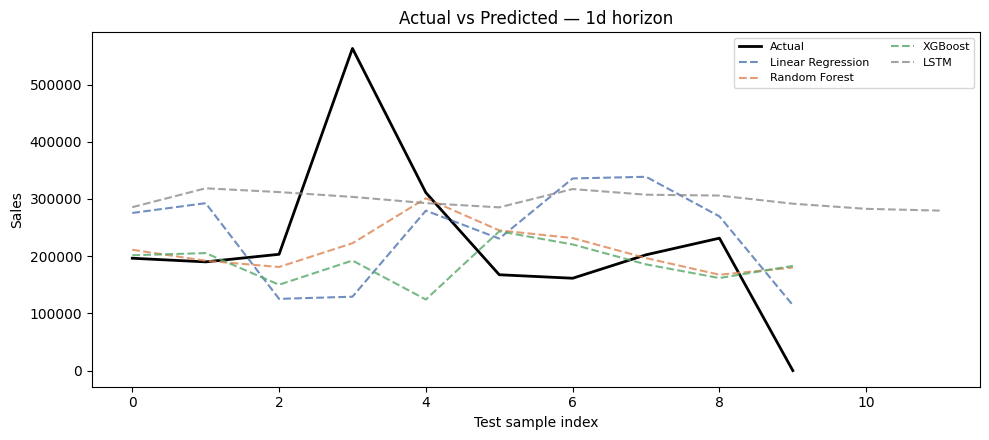

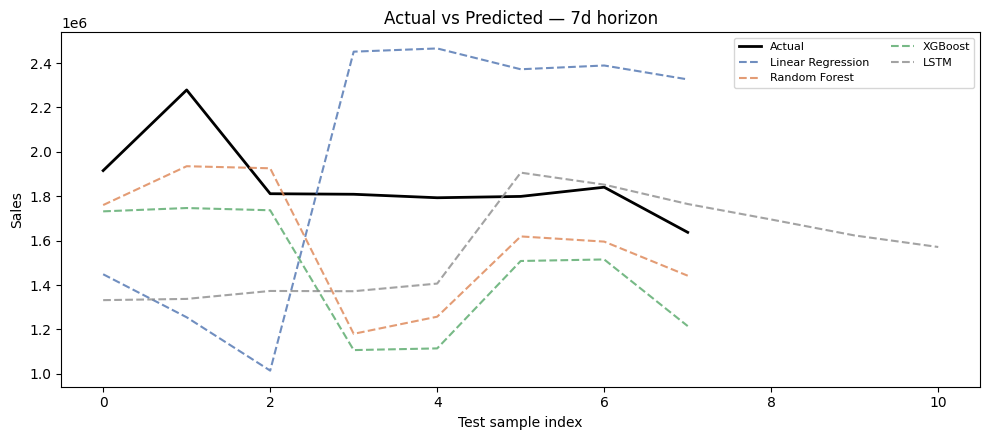

In [21]:
# Actual vs predicted, per horizon, all models that ran
palette = {"lr":"#4C72B0","rf":"#DD8452","xgb":"#55A868","lstm":"#8C8C8C"}

for h in horizon_feats:
    models_run = all_predictions[h]
    if not models_run:
        continue
    fig, ax = plt.subplots(figsize=(10,4.5))
    plotted_actual = False
    for name, pr in models_run.items():
        y_test, pred = pr["y_test"], pr["pred"]
        if not plotted_actual:
            ax.plot(range(len(y_test)), y_test, label="Actual", color="black", linewidth=2)
            plotted_actual = True
        ax.plot(range(len(pred)), pred, label=MODEL_LABELS[name], color=palette.get(name),
                 linestyle="--", alpha=0.8)
    ax.set_title(f"Actual vs Predicted — {h} horizon")
    ax.set_xlabel("Test sample index")
    ax.set_ylabel("Sales")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


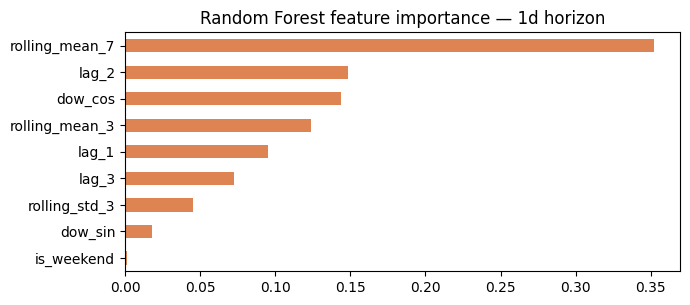

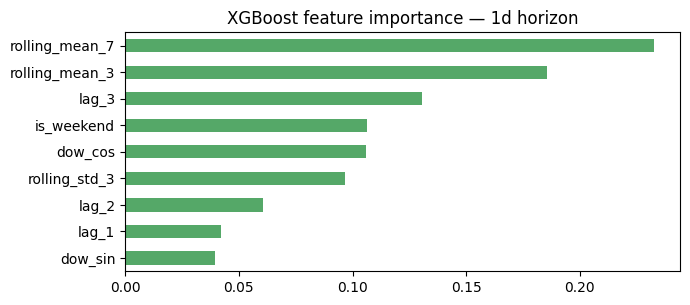

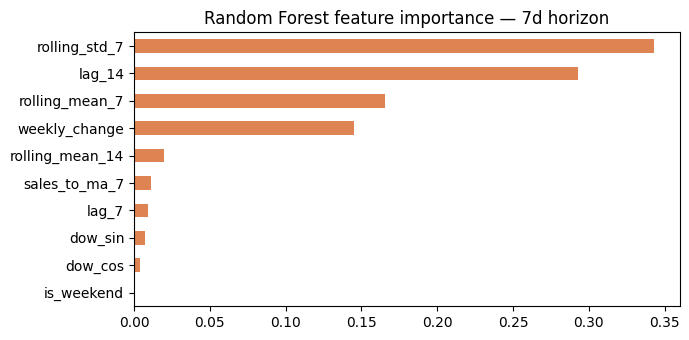

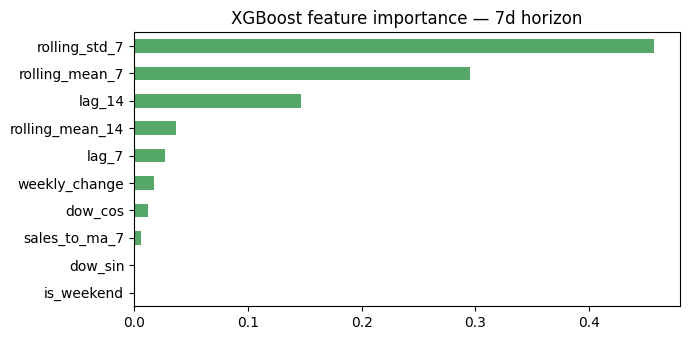

In [22]:
# Feature importance — tree-based tabular models only (RF & XGBoost)
for h, models in tabular_results.items():
    feats = datasets[h]["feats"]
    for name in ["rf", "xgb"]:
        if name not in models:
            continue
        imp = pd.Series(models[name].feature_importances_, index=feats).sort_values()
        fig, ax = plt.subplots(figsize=(7, max(2.5, 0.35*len(imp))))
        imp.plot(kind="barh", ax=ax, color=palette.get(name))
        ax.set_title(f"{MODEL_LABELS[name]} feature importance — {h} horizon")
        plt.tight_layout()
        plt.show()


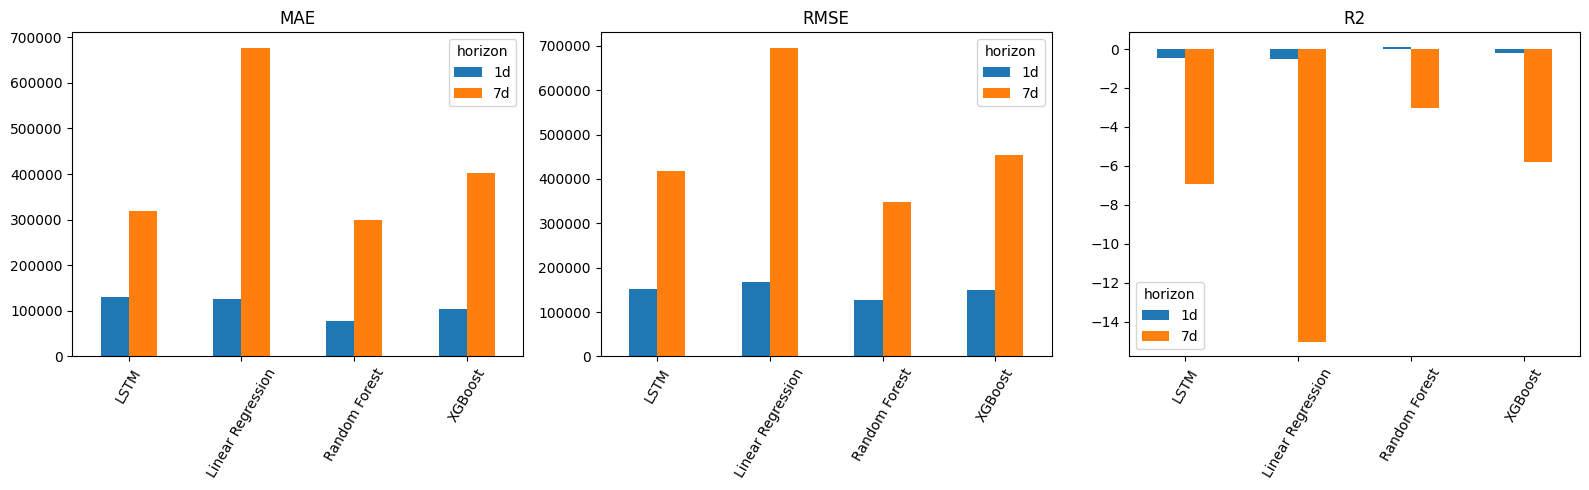

In [23]:
# Performance comparison across horizons, all 4 models
if len(metrics_df):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
        piv = metrics_df.pivot(index="model", columns="horizon", values=metric)
        piv = piv.reindex(columns=[c for c in ["1d","7d"] if c in piv.columns])
        piv.plot(kind="bar", ax=ax)
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=60)
    plt.tight_layout()
    plt.show()


## Interpretation & Recommendations

* Best model: Random Forest — lowest MAE at both 1-day (78,684) and 7-day (299,902).
* Tabular vs LSTM: mixed. LSTM worst at 1-day, but 2nd-best at 7-day (beat XGBoost, Linear Regression).
* R² vs MAPE disagree on which horizon is better. 1-day has the only positive R² (+0.10), but its MAPE (16k-33k%) is inflated by near-zero actuals in the test set. 7-day has strong MAPE/hit-rate (~16% MAPE, 87.5% within 30%) but very negative R² (-3 to -15).
* Limitations: only 8-12 test points per horizon — rankings could shift with more data.
* Next steps: more data before trusting either horizon fully; check which days drive the 1-day MAPE spike; consider ensembling Random Forest + LSTM.